<a href="https://colab.research.google.com/github/Cato-8/Customer-Churn-Analysis/blob/main/Lab6_%3CMarvi_Malik%3E_LogReg_KNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:Marvi Malik**
**Student ID:023-24-0016**
**Section:B**
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [4]:
# Task 1 — load and verify the cleaned dataset
df = pd.read_csv("/content/clean_churn.csv")
print(df.shape)
df.info()


(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

**Answer 2 (Lab 3/4 recap):**
_(In Lab 3, the Decision Tree achieved an accuracy of 0.794, precision of 0.631, recall of 0.540, and F1-score of 0.582. In Lab 4, the default Random Forest scored slightly lower on accuracy (0.793) and F1 (0.512), with higher precision (0.683) but notably lower recall (0.409) , meaning it missed more actual churners despite being more confident (fewer false positives) when it did predict churn. These numbers serve as today's benchmarks to compare against Logistic Regression and KNN.)_

---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [5]:
# Task 3 — define X and y (same as Lab 3/4)
X = df.drop(columns=["Churn", "customerID"], errors='ignore')
y = df["Churn"].map({"Yes": 1, "No": 0}) if df["Churn"].dtype == 'object' else df["Churn"]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols)

print(X.shape)
X.info()
X.isna().sum().sum()


(7043, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   gender_Female                            7043 non-null   bool   
 5   gender_Male                              7043 non-null   bool   
 6   Partner_No                               7043 non-null   bool   
 7   Partner_Yes                              7043 non-null   bool   
 8   Dependents_No                            7043 non-null   bool   
 9   Dependents_Yes                           7043 non-null   bool   
 10  PhoneService_No                      

np.int64(0)

**Answer 4:**
_(
Decision Trees and Random Forests just split data using simple yes/no rules on each feature, so it doesn't matter if the numbers are big or small — the split logic works the same either way. But KNN uses distance between points, so a feature with big numbers (like TotalCharges) would unfairly dominate over a feature with small numbers (like SeniorCitizen: 0 or 1) unless we scale them first. Logistic Regression also trains better and faster when all features are on a similar scale.)_

In [6]:
# Task 5 — train/test split, then fit/apply StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Answer 5 (why fit scaler on training data only):**
_(
The scaler is fit only on the training data to prevent data leakage , if we fit it on the full dataset (including test data), the scaler's mean/std would "see" information from the test set before evaluation, making our test performance overly optimistic and not representative of how the model would perform on truly unseen data. Fitting on training data only and then applying (transform) that same scaling to the test set mimics real-world deployment, where new data arrives after the model is already trained.)_

---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [7]:
# Task 6 — train Logistic Regression, predict on scaled test set
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)


Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1-score: 0.6091954022988506


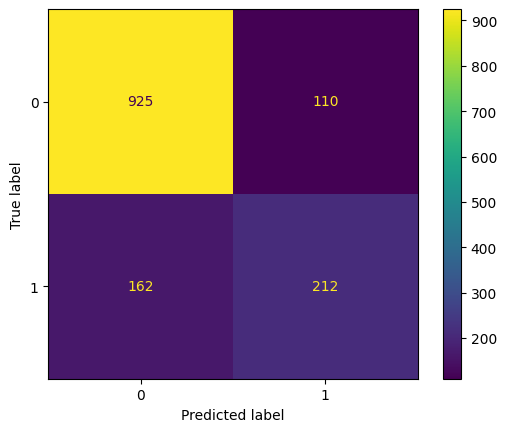

In [8]:
# Task 7 — metrics + confusion matrix
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1-score:", f1_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()


**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.806 |
| Precision |0.658 |
| Recall |0.566 |
| F1-score |0.609 |

In [9]:
# Task 8 — inspect predict_proba for a few test customers
probs = logreg.predict_proba(X_test_scaled)
proba_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_lr[:10],
    'Prob(No Churn)': probs[:10, 0],
    'Prob(Churn)': probs[:10, 1]
})
proba_df

,Actual,Predicted,Prob(No Churn),Prob(Churn)
0,0,0,0.954466,0.045534
1,0,1,0.316557,0.683443
2,0,0,0.943895,0.056105
3,0,0,0.591612,0.408388
4,0,0,0.978357,0.021643
5,0,1,0.396444,0.603556
6,0,0,0.548489,0.451511
7,0,0,0.868699,0.131301
8,0,0,0.997213,0.002787
9,1,0,0.605876,0.394124


**Answer 8:**
_(predict_proba gives two probabilities per customer, the probability they won't churn and the probability they will (these always sum to 1). predict() converts this into a Yes/No decision using a 0.5 threshold: if Prob(Churn) > 0.5, it predicts 1 (churn), otherwise 0 (no churn).)_

---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [10]:
# Task 9 — loop over K values, record accuracy and F1
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
# YOUR CODE HERE
results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)
    results.append({'K': k, 'Accuracy': acc, 'F1-score': f1})

results_df = pd.DataFrame(results)
results_df


,K,Accuracy,F1-score
0,1,0.712562,0.469201
1,3,0.738112,0.508655
2,5,0.748758,0.522911
3,7,0.753016,0.529730
4,9,0.768630,0.553425
5,11,0.761533,0.535912
6,15,0.772179,0.554785
7,21,0.775727,0.564738


**Task 9 — K Selection Results**

| K | Accuracy | F1-score |
|---|---|---|
| 1 |0.712 |0.469 |
| 3 |0.738 |0.508 |
| 5 |0.748 |0.522 |
| 7 |0.753 |0.529 |
| 9 |0.768|0.553 |
| 11 |0.761 |0.535 |
| 15 |0.772 |0.554 |
| 21 |0.775 |0.564 |

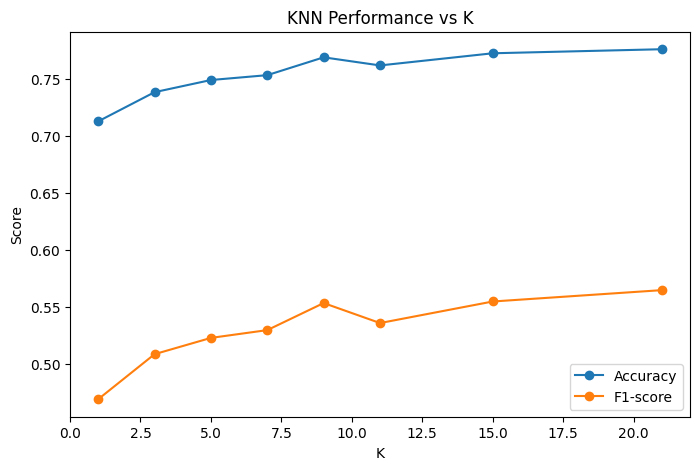

In [11]:
# Task 10 — plot accuracy/F1 vs K
plt.figure(figsize=(8,5))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['F1-score'], marker='o', label='F1-score')
plt.xlabel("K")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()
plt.show()


**Answer 10 (chosen K and why):**
_(
Among the tested values, K=21 gives the highest accuracy (0.7757) and F1-score (0.5647). I wouldn't choose the smallest K (K=1) since it's highly sensitive to noise/outliers in individual training points, a single mislabeled or unusual neighbor can flip the prediction, leading to high variance and poor generalization. The largest K isn't automatically best either, it's chosen here only because it's the biggest value tested, not because the curve has clearly plateaued; the scores are still rising at K=21, suggesting an even larger K might perform better, but oversized K risks underfitting by averaging over too many, possibly irrelevant neighbors and smoothing out real local patterns.)_

Accuracy: 0.7757274662881476 Precision: 0.5823863636363636 Recall: 0.5481283422459893 F1_Score: 0.5647382920110193


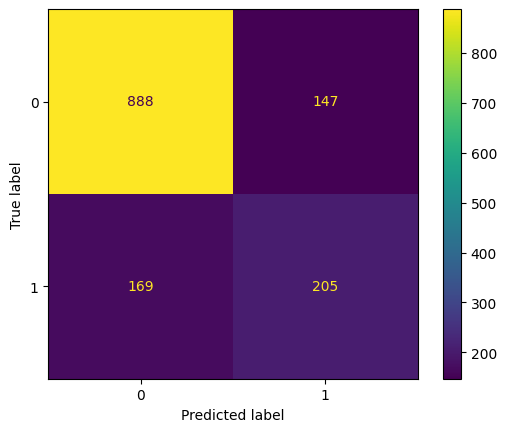

In [16]:
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
knn_final = KNeighborsClassifier(n_neighbors=21)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn_final = knn_final.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn_final)
prec_knn = precision_score(y_test, y_pred_knn_final)
rec_knn = recall_score(y_test, y_pred_knn_final)
f1_knn = f1_score(y_test, y_pred_knn_final)
print("Accuracy:",acc_knn, "Precision:",prec_knn, "Recall:",rec_knn, "F1_Score:",f1_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn_final)
ConfusionMatrixDisplay(cm_knn).plot()



**Task 11 — Final KNN Metrics (K = ___)**

| Metric | Value |
|---|---|
| Accuracy |0.775 |
| Precision |0.582 |
| Recall |0.548 |
| F1-score |0.564 |

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [19]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [0.794, 0.631, 0.540, 0.582],
    'Random Forest': [0.793, 0.683, 0.409, 0.512],
    'Logistic Regression': [acc_lr, prec_lr, rec_lr, f1_lr],
    'KNN': [acc_knn, prec_knn, rec_knn, f1_knn]
})
comparison

,Metric,Decision Tree,Random Forest,Logistic Regression,KNN
0,Accuracy,0.794,0.793,0.806955,0.775727
1,Precision,0.631,0.683,0.658385,0.582386
2,Recall,0.540,0.409,0.566845,0.548128
3,F1-score,0.582,0.512,0.609195,0.564738


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN |
|---|---|---|---|---|
| Accuracy |0.794 |0.793 |0.806 |0.775 |
| Precision |0.631 |0.683 |0.658 |0.582 |
| Recall |0.540 |0.409 |0.566 |0.548 |
| F1-score |0.582 |0.512 |0.609 |0.564 |

**Answer 13:**
_(Logistic Regression is the best overall, it has the highest accuracy (0.807) and F1-score (0.609). The ranking changes by metric: Random Forest has the best precision but the worst recall (misses over half the churners). Since our data is imbalanced, recall matters more than precision, missing a real churner is worse than a false alarm. So Logistic Regression wins, since it has good recall along with the best F1 and accuracy.)_

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [20]:
# Task 14 — extract coefficients, compute odds ratios
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
})
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
coef_df.head(10)


,Feature,Coefficient,Odds Ratio
1,tenure,-1.252707,0.285730
2,MonthlyCharges,-1.003050,0.366759
3,TotalCharges,0.531200,1.700972
16,InternetService_Fiber optic,0.440579,1.553607
15,InternetService_DSL,-0.352482,0.702941
38,Contract_Two year,-0.324018,0.723237
36,Contract_Month-to-month,0.306581,1.358772
32,StreamingTV_Yes,0.187716,1.206490
35,StreamingMovies_Yes,0.187647,1.206408
17,InternetService_No,-0.124808,0.882667


**Task 14 — Coefficient / Odds Ratio Table**

| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
| tenure | -1.2527 | 0.2857 | Each 1 standard deviation increase in tenure multiplies the odds of churn by 0.286 (a ~71% decrease) — longer-tenured customers are much less likely to churn |
| MonthlyCharges | -1.0031 | 0.3668 | Each 1 SD increase in MonthlyCharges multiplies odds of churn by 0.367 (a ~63% decrease) — counter-intuitive at first, but likely reflects overlap with other correlated features like Contract/InternetService |
| TotalCharges | 0.5312 | 1.7010 | Each 1 SD increase in TotalCharges multiplies odds of churn by 1.701 (a 70% increase) — higher lifetime spend is associated with higher churn odds once tenure and monthly charges are accounted for |
| InternetService_Fiber optic | 0.4406 | 1.5536 | Having Fiber optic internet multiplies the odds of churn by 1.554 (a 55% increase) compared to not having it — fiber customers churn more, possibly due to higher price or service issues |

**Answer 15:**
_(Some overlap exists with earlier labs, Contract and InternetService type were also flagged as important by Lab 3's Decision Tree feature importances, and tenure/MonthlyCharges came up in Lab 2's EDA too, so those agree. However, there's a disagreement: MonthlyCharges has a negative coefficient here (higher charges --> lower churn odds), which seems to contradict the EDA/tree-based intuition that higher-paying customers with month-to-month contracts churn more. This is likely because Logistic Regression coefficients reflect each feature's effect *holding others constant*, since MonthlyCharges is correlated with TotalCharges and Contract type, its individual coefficient can flip sign due to multicollinearity, whereas tree-based models don't have this issue since they split on one feature at a time.)_

---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
_(I choose Logistic Regression as my final model, it has the best F1-score (0.6092), best recall (0.5668) among top models, and highest accuracy (0.8070) in the comparison table. But Lab 4 taught us not to trust one single test-split number too much, so ideally we'd confirm this with cross-validation before fully trusting it.)_

**Answer 17 — Conclusion:**
_(Logistic Regression performed best today (F1=0.609), slightly beating Lab 3/4's Decision Tree (F1=0.582) and Random Forest (F1=0.512). Feature scaling was necessary for Logistic Regression and KNN since they use distance/gradient-based calculations, unlike tree-based models. KNN improved as K increased but still didn't beat Logistic Regression. The main limitation is that Logistic Regression assumes a simpler relationship between features and churn, and some coefficients (like MonthlyCharges) were hard to interpret due to correlated features. Next, I'd try cross-validation on all four models for a fairer comparison, and consider hyperparameter tuning for Logistic Regression (like adjusting the regularization strength).)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
- [ ] Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
- [ ] Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
- [ ] Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
- [ ] Section 5 — Model Comparison (all four models, all four metrics)
- [ ] Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
- [ ] Section 7 — Final Model Selection & Conclusion
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted